# 🧠 Ejercicio Guiado de Machine Learning en Psicología
**Autores:**
- Miguel David Dávila Palomino
- Diego Santiago Yáñez Chile
- María Fernanda Zárate Prado

*Redes:* [@neuropucp](https://www.instagram.com/neuropucp)

---

## Preguntas guía
1. ¿Podemos predecir el **nivel de bienestar** de un paciente basándonos en sus **horas de terapia**?
2. ¿Mejora nuestra predicción si añadimos una segunda variable, como las **horas de sueño**?
3. ¿Qué pasa cuando comparamos el método matemático clásico con el algoritmo moderno usado en Redes Neuronales (Descenso de Gradiente)?

Vamos a enseñarle a una máquina a encontrar estas relaciones a partir de datos simulados.

## 0. Mini actividad: leer documentación oficial

Antes de ejecutar, dale una lectura rápida a estos enlaces oficiales de `scikit-learn`:

- `LinearRegression`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- `SGDRegressor`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html
- `StandardScaler`: https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html

### ❓ Preguntas para reflexionar (puedes responder en clase)
1. `LinearRegression` usa un método llamado "Mínimos Cuadrados Ordinarios" (OLS). ¿Es un método iterativo o resuelve una ecuación exacta?
2. Según la documentación de `SGDRegressor`, ¿qué significa "Stochastic Gradient Descent" y por qué recomiendan escalar los datos antes de usarlo?
3. ¿Qué hace exactamente `StandardScaler` con la media y la varianza de los datos?


## 1. Importar librerías

🎯 **Objetivo:** Preparar nuestras herramientas de trabajo.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42) # Fijamos la semilla para reproducibilidad

## 2. Las Matemáticas detrás de la Magia (Modelos y Funciones de Costo)

Antes de programar, es vital entender qué intenta hacer la computadora.

**1. La Hipótesis (Regresión Lineal Múltiple):**
Buscamos encontrar los parámetros (pesos) $\theta$ que mejor tracen una línea/plano a través de los datos:
$$ \hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n $$

**2. La Función de Costo (Mean Squared Error - MSE):**
Para saber si nuestra línea es buena, calculamos el error. El **MSE** es la métrica de costo matemática exacta $J(\theta)$ que la máquina intenta minimizar reduciendo la distancia al cuadrado entre la predicción y el valor real:
$$ J(\theta) = \text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 $$

**3. RMSE (Raíz del Error Cuadrático Medio):**
El MSE nos da el error "al cuadrado". Para reportarlo en las **mismas unidades** que medimos (ej. puntos de bienestar), usamos su raíz cuadrada:
$$ \text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} $$

**4. El Coeficiente de Determinación ($R^2$):**
Mide qué porcentaje de la varianza es explicada por nuestro modelo (1.0 es perfecto, 0 es como predecir siempre el promedio).
$$ R^2 = 1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2} $$

**5. Mínimos Cuadrados Ordinarios (OLS) vs Descenso de Gradiente (SGD):**
* **OLS** calcula la respuesta perfecta con una sola ecuación matemática matricial (pesada para memoria en Big Data):
$$ \hat{\theta} = (X^T X)^{-1} X^T y $$
* **SGD** es iterativo. Da pasos hacia abajo en la curva de error buscando el punto más bajo. Es la base de las Redes Neuronales ($\alpha$ es el *learning rate*):
$$ \theta_j := \theta_j - \alpha \frac{\partial}{\partial \theta_j} J(\theta) $$

## 3. Crear un dataset sintético (2 Predictores)

🎯 **Objetivo:** Simular datos clínicos de 150 pacientes.

Variables predictoras (X):
- `horas_terapia`: Horas de TCC recibidas al año (de 0 a 60).
- `horas_sueno`: Promedio de horas de sueño diario (de 4 a 10).

Variable a predecir (y):
- `bienestar`: Puntaje del 0 al 100.

La "Verdad Oculta" será: `bienestar = 15 + (0.8 * terapia) + (3.5 * sueño) + ruido`

,horas_terapia,horas_sueno,bienestar
0,22.472407,9.449595,66.279369
1,57.042858,5.437371,76.407085
2,43.919637,4.869369,77.898222
3,35.919509,6.936717,71.183710
4,9.361118,9.913903,47.061841


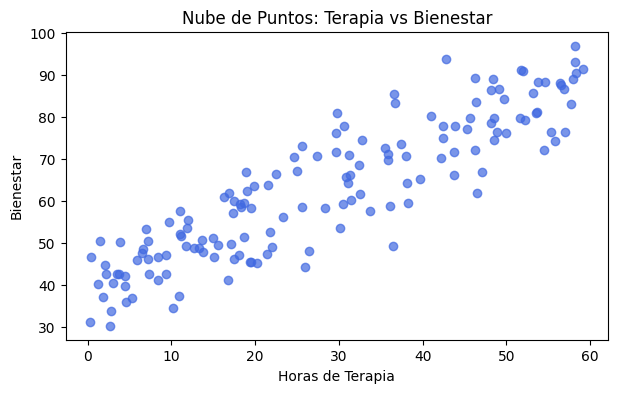

In [ ]:
n_pacientes = 150
horas_terapia = np.random.uniform(0, 60, n_pacientes)
horas_sueno = np.random.uniform(4, 10, n_pacientes)

# Generamos el bienestar basado en ambas variables + variabilidad humana (ruido)
ruido = np.random.normal(0, 5, n_pacientes)
bienestar = 15 + (0.8 * horas_terapia) + (3.5 * horas_sueno) + ruido
bienestar = np.clip(bienestar, 0, 100) # Limitamos entre 0 y 100

df = pd.DataFrame({
    "horas_terapia": horas_terapia,
    "horas_sueno": horas_sueno,
    "bienestar": bienestar
})

display(df.head())

# Visualizamos Terapia vs Bienestar
plt.figure(figsize=(7, 4))
plt.scatter(df["horas_terapia"], df["bienestar"], alpha=0.7, color='royalblue')

# 💡 PISTA: Para agregar visualmente la línea de regresión una vez que
# entrenemos el modelo más adelante, usaríamos una línea de código como esta:
# plt.plot(X_test, predicciones, color='red', linewidth=2)

plt.xlabel("Horas de Terapia")
plt.ylabel("Bienestar")
plt.title("Nube de Puntos: Terapia vs Bienestar")
plt.show()

## 4. Separar Entrenamiento y Prueba

🎯 **Objetivo:** Guardar un 20% de los datos como "examen sorpresa" para evaluar si nuestros modelos realmente aprenden a generalizar.

In [ ]:
# X contendrá nuestros DOS predictores, y contendrá el objetivo
X = df[["horas_terapia", "horas_sueno"]]
y = df["bienestar"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)
print(f"Entrenamiento: {X_train.shape[0]} pacientes | Prueba: {X_test.shape[0]} pacientes")

Entrenamiento: 120 pacientes | Prueba: 30 pacientes


## 5. Comparación de Modelos: Simple vs Múltiple (Gradient Descent)

¿Es válido comparar modelos con diferente cantidad de variables? **¡Sí, es la base del Machine Learning!** Se llama "Feature Selection". Queremos demostrar estadísticamente si añadir el `sueño` a la ecuación realmente ayuda.

🎯 **Objetivo:** Entrenar el Modelo 1 (solo terapia) y el Modelo 2 (terapia + sueño) usando Descenso de Gradiente (`SGDRegressor`) y comparar sus errores.

In [ ]:
# PREPARAMOS LOS DATOS:
# Para el Modelo 1, extraemos solo la columna de Terapia (dejando formato de tabla [[]])
X_train_simple = X_train[["horas_terapia"]]
X_test_simple = X_test[["horas_terapia"]]

# ENTRENAMIENTO (USANDO DESCENSO DE GRADIENTE EN AMBOS):
# Recuerda: SGD siempre requiere que escalemos los datos primero.
modelo_1 = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, random_state=42)
)
modelo_1.fit(X_train_simple, y_train)

modelo_2 = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, random_state=42)
)
modelo_2.fit(X_train, y_train) # Usa ambas columnas

# PREDICCIONES:
preds_mod1 = modelo_1.predict(X_test_simple)
preds_mod2 = modelo_2.predict(X_test)

# EVALUACIÓN:
print("=== MODELO 1 (Solo Terapia) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_mod1)):.2f}")
print(f"R²:   {r2_score(y_test, preds_mod1):.3f}\n")

print("=== MODELO 2 (Terapia + Sueño) ===")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, preds_mod2)):.2f}")
print(f"R²:   {r2_score(y_test, preds_mod2):.3f}\n")

print("💡 CONCLUSIÓN:")
print("El Modelo 2 tiene un RMSE menor y un R² mayor. Matemáticamente, añadir las horas de sueño mejoró nuestra capacidad de predecir el bienestar.")

=== MODELO 1 (Solo Terapia) ===
RMSE: 8.09
R²:   0.750

=== MODELO 2 (Terapia + Sueño) ===
RMSE: 5.01
R²:   0.904

💡 CONCLUSIÓN:
El Modelo 2 tiene un RMSE menor y un R² mayor. Matemáticamente, añadir las horas de sueño mejoró nuestra capacidad de predecir el bienestar.


## 6. El Duelo de Estimadores: SGD vs OLS Clásico [OPCIONAL]

Hasta ahora hemos usado **Descenso de Gradiente Estocástico (SGD)**. Este algoritmo iterativo es la norma en el Machine Learning moderno, domina el Big Data y es la matemática base de las Redes Neuronales.

Sin embargo, existe el método estadístico clásico llamado **Mínimos Cuadrados Ordinarios (OLS)** (`LinearRegression` en scikit-learn). OLS no aprende paso a paso; utiliza una fórmula matemática de álgebra lineal para encontrar la respuesta perfecta en un solo cálculo.

Es perfecto para 150 filas, pero si tuvieras 5 millones de pacientes, OLS colapsaría la memoria de tu computadora. ¡Veamos si hay diferencias de rendimiento en nuestro pequeño dataset!

In [ ]:
# 1. Entrenamos el modelo clásico OLS (con las 2 variables)
modelo_ols = LinearRegression()
modelo_ols.fit(X_train, y_train)
preds_ols = modelo_ols.predict(X_test)

# 2. Recuperamos las predicciones de nuestro Modelo 2 (SGD) que ya entrenamos arriba
preds_sgd = preds_mod2

print("=== COMPARACIÓN: SGDRegressor vs OLS Clásico ===")
print(f"R² SGD (Iterativo): {r2_score(y_test, preds_sgd):.4f}")
print(f"R² OLS (Exacto):    {r2_score(y_test, preds_ols):.4f}")

# ¡Notarás que ambos obtienen resultados prácticamente idénticos!
# El Descenso de Gradiente logró encontrar la solución matemática perfecta
# a través de su proceso de aprendizaje iterativo.

=== COMPARACIÓN: SGDRegressor vs OLS Clásico ===
R² SGD (Iterativo): 0.9041
R² OLS (Exacto):    0.9038


## 7. Visualizando el Descenso de Gradiente: Loss vs Accuracy (R²) [OPCIONAL]

Vamos a ver cómo aprende el SGD iteración tras iteración (épocas). Haremos dos gráficas en paralelo:
1. **Curva de Pérdida (Loss Curve):** Monitorea el MSE. Queremos que baje.
2. **Curva de "Exactitud" (R² Score):** En regresión no usamos *Accuracy*, sino R². Queremos que suba y se acerque a 1.0.

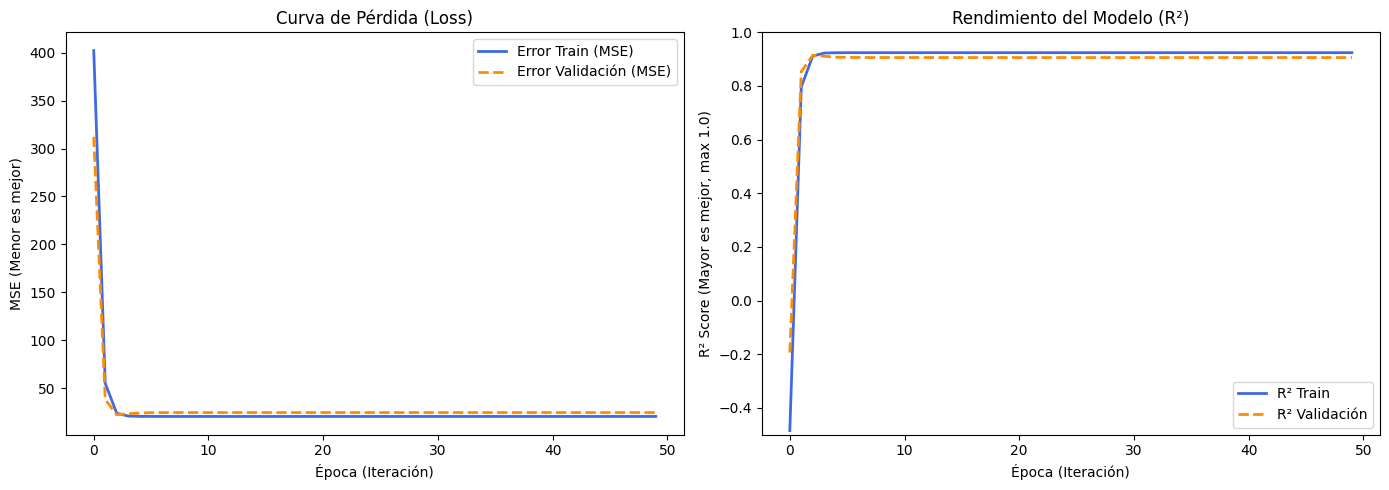

💡 Observa la magia: El Error (MSE) colapsa rápidamente, mientras que la 'Exactitud' (R²) sube rápidamente y se estabiliza.


In [ ]:
# Escalamos los datos manualmente para este experimento paso a paso
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Configuramos SGD para que aprenda manualmente (1 iteración a la vez con warm_start)
sgd_step = SGDRegressor(max_iter=1, tol=None, warm_start=True, penalty=None, learning_rate='constant', eta0=0.01, random_state=42)

# Listas para guardar las métricas en cada paso
errores_train, errores_test = [], []
r2_train_list, r2_test_list = [], []
epocas = 50

for epoca in range(epocas):
    sgd_step.partial_fit(X_train_s, y_train)

    # Predicciones en la época actual
    pred_train = sgd_step.predict(X_train_s)
    pred_test = sgd_step.predict(X_test_s)

    # Guardamos MSE (Pérdida/Loss)
    errores_train.append(mean_squared_error(y_train, pred_train))
    errores_test.append(mean_squared_error(y_test, pred_test))

    # Guardamos R2 (El análogo a "Accuracy" en Regresión)
    r2_train_list.append(r2_score(y_train, pred_train))
    r2_test_list.append(r2_score(y_test, pred_test))

# --- CREACIÓN DE LOS GRÁFICOS --- #
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: MSE (Loss)
ax1.plot(range(epocas), errores_train, label='Error Train (MSE)', color='royalblue', linewidth=2)
ax1.plot(range(epocas), errores_test, label='Error Validación (MSE)', color='darkorange', linewidth=2, linestyle='dashed')
ax1.set_title('Curva de Pérdida (Loss)')
ax1.set_xlabel('Época (Iteración)')
ax1.set_ylabel('MSE (Menor es mejor)')
ax1.legend()

# Gráfica 2: R² (Rendimiento)
ax2.plot(range(epocas), r2_train_list, label='R² Train', color='royalblue', linewidth=2)
ax2.plot(range(epocas), r2_test_list, label='R² Validación', color='darkorange', linewidth=2, linestyle='dashed')
ax2.set_title('Rendimiento del Modelo (R²)')
ax2.set_xlabel('Época (Iteración)')
ax2.set_ylabel('R² Score (Mayor es mejor, max 1.0)')
ax2.set_ylim(-0.5, 1.0) # Limitamos el eje Y inferior para ver mejor la subida
ax2.legend()

plt.tight_layout()
plt.show()

print("💡 Observa la magia: El Error (MSE) colapsa rápidamente, mientras que la 'Exactitud' (R²) sube rápidamente y se estabiliza.")

## 8. Curvas de Aprendizaje por Tamaño de Muestra [OPCIONAL]

Otra métrica excelente es ver cómo el modelo mejora a medida que le damos **más cantidad de datos**.
Si la curva de error se estabiliza rápido, significa que encuestar a miles de pacientes extra ya no ayudará tanto.

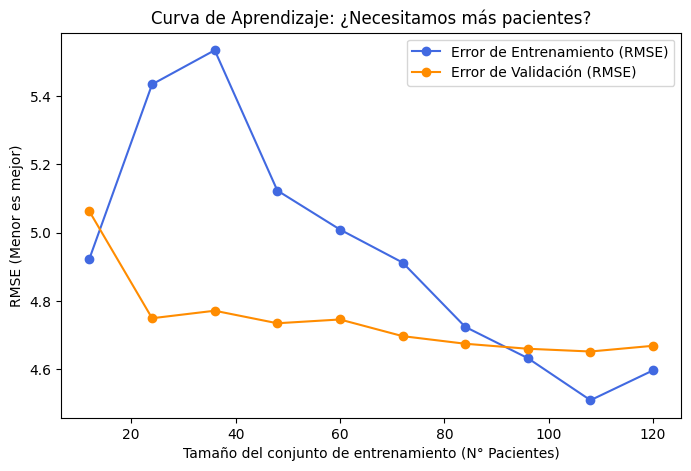

In [ ]:
# Extraemos el MSE negativo y calculamos promedios usando el Modelo 2 (SGD)
train_sizes, train_scores, test_scores = learning_curve(
    modelo_2, X, y, cv=5, scoring='neg_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), random_state=42
)

# Convertimos los scores (negativos por convención de sklearn) a RMSE positivo
train_rmse = np.sqrt(-train_scores.mean(axis=1))
test_rmse = np.sqrt(-test_scores.mean(axis=1))

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_rmse, 'o-', color='royalblue', label='Error de Entrenamiento (RMSE)')
plt.plot(train_sizes, test_rmse, 'o-', color='darkorange', label='Error de Validación (RMSE)')
plt.title('Curva de Aprendizaje: ¿Necesitamos más pacientes?')
plt.xlabel('Tamaño del conjunto de entrenamiento (N° Pacientes)')
plt.ylabel('RMSE (Menor es mejor)')
plt.legend()
plt.show()

---
## 9. 🧠 Ejercicio Guiado: Tu turno

> **Escenario Clínico:**
> Quieres predecir el **nivel de ansiedad clínico** (0-100) de pacientes adolescentes. Tienes un dataset con los **minutos diarios de uso de TikTok**.

### 📋 Instrucciones
Sigue los ✏️ **TODO** en las celdas de abajo para construir tu propio modelo utilizando Gradient Descent. ¡No copies y pegues ciegamente, adapta el código!

In [ ]:
# --- DATOS SINTÉTICOS PARA TU EJERCICIO ---
minutos_tiktok = np.random.uniform(30, 300, 200)
ansiedad_base = 20 + (0.18 * minutos_tiktok) + np.random.normal(0, 8, 200)
ansiedad_base = np.clip(ansiedad_base, 0, 100)

df_ejercicio = pd.DataFrame({
    "minutos_tiktok": minutos_tiktok,
    "ansiedad": ansiedad_base
})

df_ejercicio.head(3)

,minutos_tiktok,ansiedad
0,155.198569,50.013522
1,125.405102,35.338385
2,187.587150,58.874427


In [ ]:
# ✏️ TODO 1: Define tus variables X e y (¡recuerda los corchetes de X!)

# X_ej = ...
# y_ej = ...

# ✏️ TODO 2: Divide los datos (80% train, 20% test)

# X_train_ej, X_test_ej, y_train_ej, y_test_ej = train_test_split(..., ..., test_size=..., random_state=42)


In [ ]:
# ✏️ TODO 3: Crea un Pipeline que escale los datos (StandardScaler) y
# luego aplique SGDRegressor. Entrénalo y haz predicciones sobre X_test_ej

# mi_modelo = make_pipeline(..., ...)
# mi_modelo.fit(..., ...)
# predicciones_ej = mi_modelo.predict(...)


In [ ]:
# ✏️ TODO 4: Evalúa tu modelo. Imprime el RMSE y el R²

# rmse_ej = ...
# r2_ej = ...

# print(f"El Error (RMSE) es: {rmse_ej:.2f} puntos de ansiedad")
# print(f"El R² es: {r2_ej:.2f}")


### ❓ Preguntas de Reflexión (Edita esta celda)

1. Revisa el peso asignado extrayéndolo con `mi_modelo.named_steps['sgdregressor'].coef_[0]`. ¿La relación fue positiva o negativa? ¿Qué significa clínicamente?
*Tu respuesta aquí...*

2. Vuelve a ejecutar todo el código del ejercicio cambiando los `minutos_tiktok` por valores mucho más grandes en la celda de generación de datos. ¿Por qué es crucial el `StandardScaler` en este tipo de algoritmos?
*Tu respuesta aquí...*


---
## 10. 🗝️ Solucionario del Ejercicio
Si te atascaste o quieres comprobar tus respuestas, ejecuta la siguiente celda.

=== RESULTADOS DEL EJERCICIO ===
Coeficiente (Pendiente): 14.1643 (Relación Positiva: más TikTok = más ansiedad)
El Error (RMSE) es: 7.26 puntos de ansiedad
El R² es: 0.795



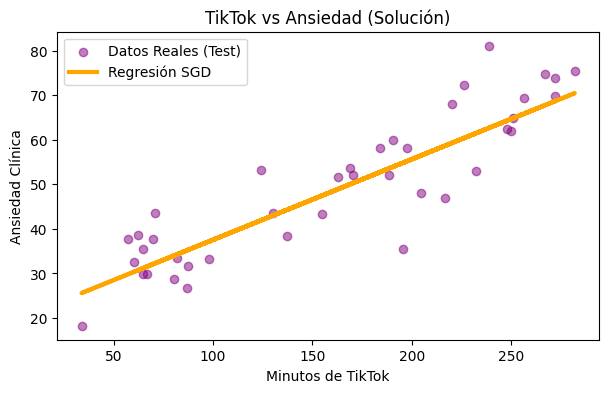

In [ ]:
# 1. Definir variables
X_ej = df_ejercicio[["minutos_tiktok"]]
y_ej = df_ejercicio["ansiedad"]

# 2. Dividir
X_train_ej, X_test_ej, y_train_ej, y_test_ej = train_test_split(X_ej, y_ej, test_size=0.2, random_state=42)

# 3. Entrenar y predecir (Con Gradient Descent)
mi_modelo = make_pipeline(
    StandardScaler(),
    SGDRegressor(max_iter=1000, random_state=42)
)
mi_modelo.fit(X_train_ej, y_train_ej)
predicciones_ej = mi_modelo.predict(X_test_ej)

# 4. Evaluar (Usando RMSE para mantener coherencia con la teoría)
rmse_ej = np.sqrt(mean_squared_error(y_test_ej, predicciones_ej))
r2_ej = r2_score(y_test_ej, predicciones_ej)

print("=== RESULTADOS DEL EJERCICIO ===")
# Para extraer el coeficiente de un pipeline, llamamos al paso específico por su nombre
coeficiente = mi_modelo.named_steps['sgdregressor'].coef_[0]
print(f"Coeficiente (Pendiente): {coeficiente:.4f} (Relación Positiva: más TikTok = más ansiedad)")
print(f"El Error (RMSE) es: {rmse_ej:.2f} puntos de ansiedad")
print(f"El R² es: {r2_ej:.3f}\n")

# 5. Gráfica con la línea de regresión
plt.figure(figsize=(7, 4))
plt.scatter(X_test_ej, y_test_ej, color='purple', alpha=0.5, label='Datos Reales (Test)')
plt.plot(X_test_ej, predicciones_ej, color='orange', linewidth=3, label='Regresión SGD')
plt.title('TikTok vs Ansiedad (Solución)')
plt.xlabel('Minutos de TikTok')
plt.ylabel('Ansiedad Clínica')
plt.legend()
plt.show()